# Exploratory Data Analysis (EDA)
### AI Reading Comprehension & Quiz Generation System

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Setup paths robustly
notebook_dir = os.getcwd()
if os.path.basename(notebook_dir) == 'notebooks':
    BASE_DIR = os.path.abspath(os.path.join(notebook_dir, ".."))
else:
    # Assume we are in the project root
    BASE_DIR = os.path.abspath(os.path.join(notebook_dir, "AI_Project_2026"))
    if not os.path.exists(BASE_DIR):
        BASE_DIR = notebook_dir

DATA_PATH = os.path.join(BASE_DIR, "processed", "train.csv")

if not os.path.exists(DATA_PATH):
    print(f"❌ Data not found at {DATA_PATH}")
    print("Please ensure you are running this from the AI_Project_2026 directory or the notebooks folder.")
    print("Also ensure src/data_splitter.py has been run.")
else:
    print(f"✅ Loading data from: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)

✅ Loading data from: /home/ahsan/Documents/Uni work/Sem 6/AI Lab/Project/AI_Project_2026/processed/train.csv


## 1. Dataset Overview

In [3]:
if 'df' in locals():
    print("--- Info ---")
    print(df.info())
    print("\n--- Missing Values ---")
    print(df.isnull().sum())

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 70292 entries, 0 to 70291
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  70292 non-null  int64
 1   id          70292 non-null  str  
 2   article     70292 non-null  str  
 3   question    70292 non-null  str  
 4   A           70289 non-null  str  
 5   B           70292 non-null  str  
 6   C           70291 non-null  str  
 7   D           70283 non-null  str  
 8   answer      70292 non-null  str  
dtypes: int64(1), str(8)
memory usage: 122.4 MB
None

--- Missing Values ---
Unnamed: 0    0
id            0
article       0
question      0
A             3
B             0
C             1
D             9
answer        0
dtype: int64


## 2. Distributions

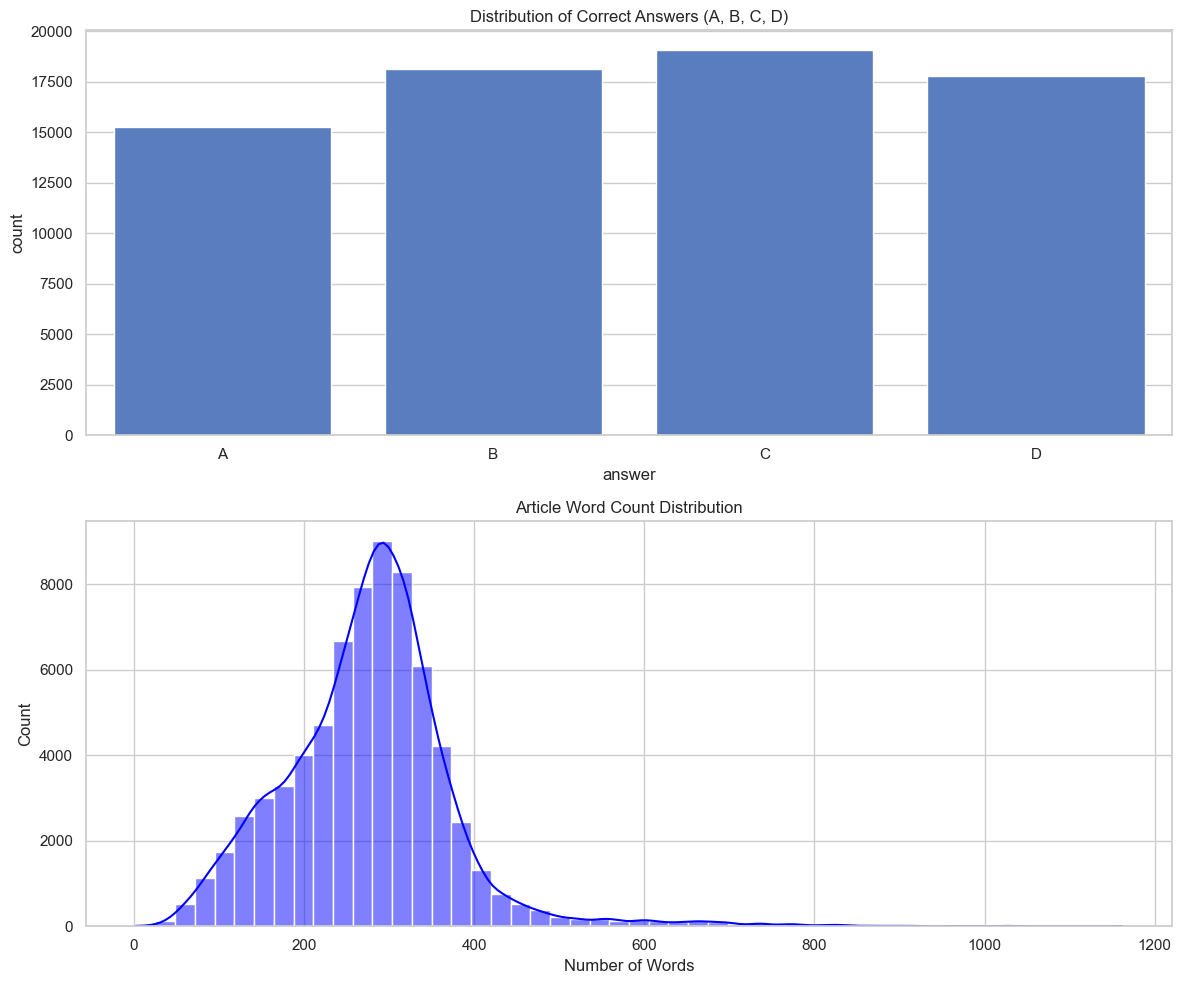

In [4]:
if 'df' in locals():
    sns.set(style="whitegrid", palette="muted")
    plt.rcParams['figure.figsize'] = (12, 10)

    # 2.1 Answer Distribution
    plt.subplot(2, 1, 1)
    sns.countplot(x='answer', data=df, order=['A', 'B', 'C', 'D'])
    plt.title("Distribution of Correct Answers (A, B, C, D)")

    # 2.2 Text Lengths
    df['article_len'] = df['article'].apply(lambda x: len(str(x).split()))
    plt.subplot(2, 1, 2)
    sns.histplot(df['article_len'], bins=50, kde=True, color='blue')
    plt.title("Article Word Count Distribution")
    plt.xlabel("Number of Words")
    
    plt.tight_layout()
    plt.show()

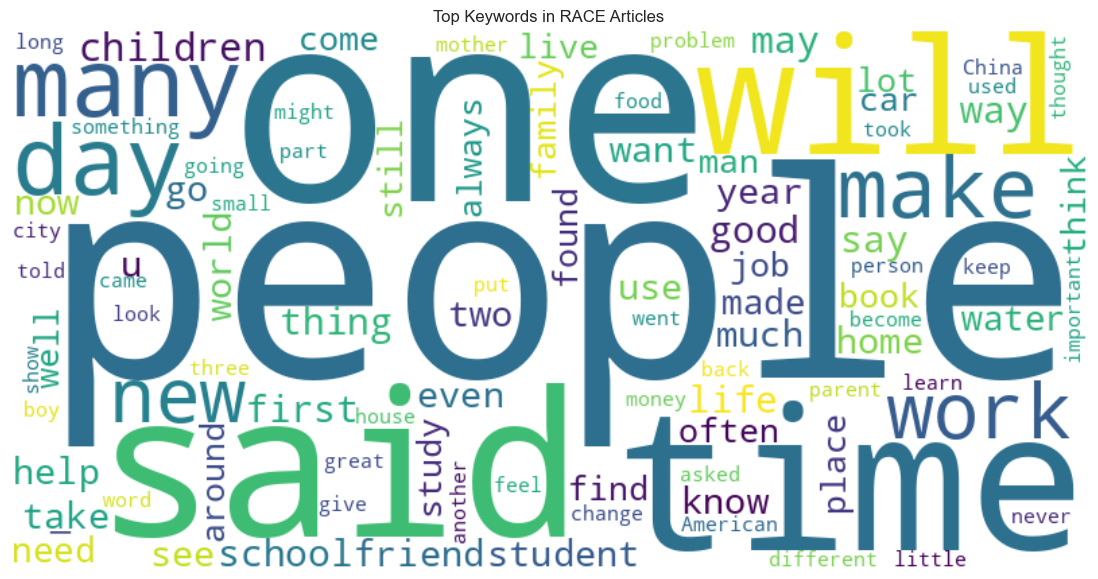

In [5]:
if 'df' in locals():
    # Word Cloud for Articles
    text = " ".join(df['article'].sample(1000).astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Top Keywords in RACE Articles")
    plt.show()